# PCA & Wavelet Correlation Comparison — Final Notebook

PCA and wavelet decomposition were already developed and validated in earlier notebooks.
This notebook re-runs both quickly and produces the two
comparison visuals needed for the thesis:

1. **Correlation heatmap** — PCA loadings vs. USGS lab spectra (grouped by mineral class)
2. **Correlation heatmap** — wavelet-decomposed PCA loadings vs. wavelet-decomposed lab spectra (scale-wise)


## 1. Imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
import urllib.request
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
import spectral
import pywt
import sys
from pathlib import Path 
import yaml

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10


## 2. Configuration

In [8]:
# ROI coordinates (adjust to your scene)
ROI_ROW1, ROI_COL1 = 931, 451
ROI_ROW2, ROI_COL2 = 1035, 579

# Project structure
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
SRC_DIR = PROJECT_ROOT / "src"

# USGS spectral library
USGS_FOLDER = DATA_DIR / "usgs_folder"

print(f"Project root: {PROJECT_ROOT}")
print(f"USGS folder: {USGS_FOLDER}")

# PCA settings
N_COMP = 15                    # Number of PCA components to extract
N_PCA_COMPONENTS = N_COMP      # alias (used by the wavelet section)

# Wavelet settings
WAVELET_TYPE = 'db4'   # Daubechies 4
DECOMP_LEVEL = 5       # DWT decomposition depth

print('  Configuration loaded')
print(f'   ROI: ({ROI_ROW1},{ROI_COL1}) to ({ROI_ROW2},{ROI_COL2})')
print(f'   Components: {N_COMP}  |  Wavelet: {WAVELET_TYPE}  |  Levels: {DECOMP_LEVEL}')


Project root: C:\Users\esppr\bachelor-thesis
USGS folder: C:\Users\esppr\bachelor-thesis\data\usgs_folder
  Configuration loaded
   ROI: (931,451) to (1035,579)
   Components: 15  |  Wavelet: db4  |  Levels: 5


In [9]:
#Path configuration
CONFIG_PATH = PROJECT_ROOT / "config" / "data_config.yaml"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Configuration file not found: {CONFIG_PATH}\n"
        "Copy config/data_config.example.yaml to "
        "config/data_config.yaml and set your local data paths."
    )

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

HDR_PATH = Path(config["enmap_hdr"])

if not HDR_PATH.exists():
    raise FileNotFoundError(
        f"EnMAP HDR file not found:\n{HDR_PATH}\n"
        "Check the path in config/data_config.yaml"
    )

print(f"Using EnMAP scene: {HDR_PATH}")

Using EnMAP scene: C:\SpecStuff\2idk\ENMAP01-____L2A-DT0000045172_20230929T185849Z_001_V010506_20260323T111352Z\ENMAP01-____L2A-DT0000045172_20230929T185849Z_001_V010506_20260323T111352Z-SPECTRAL_IMAGE.HDR


## 3. Load EnMAP Band Centers

In [10]:
from src.enmap_data import load_enmap_bands
# Download and parse EnMAP band centers
url = "https://www.enmap.org/data/doc/EnMAP_Spectral_Bands_update.xlsx"
excel_path = DATA_DIR / "EnMAP_Spectral_Bands.xlsx"

if not Path(excel_path).exists():
    print(f'Downloading EnMAP band data from {url}...')
    urllib.request.urlretrieve(url, excel_path)


enmap_centers, enmap_fwhm = load_enmap_bands(excel_path)
wl_all = np.array(enmap_centers)
print(f' Loaded {len(wl_all)} EnMAP band centers ({wl_all[0]:.1f}–{wl_all[-1]:.1f} nm)')


 Loaded 224 EnMAP band centers (418.4–2445.3 nm)


## 4. Load & Preprocess Hyperspectral Cube

In [11]:
print(f' Loading: {Path(HDR_PATH).name}\n')

if not Path(HDR_PATH).exists():
    raise FileNotFoundError(f"HDR file not found: {HDR_PATH}")

cube = spectral.open_image(HDR_PATH)
cube_data = cube.load()
print(f' Raw cube shape: {cube_data.shape}  (rows × cols × bands)')

# DN → reflectance conversion
if cube_data.max() > 10:
    cube_data = cube_data.astype(float) / 10000.0
    print(' Scaled DN → reflectance (÷10000)')
else:
    print('  Data already in reflectance units')

# Crop to ROI
r_min, r_max = sorted([ROI_ROW1, ROI_ROW2])
c_min, c_max = sorted([ROI_COL1, ROI_COL2])
cube_data = cube_data[r_min:r_max, c_min:c_max, :]
n_rows, n_cols, n_bands = cube_data.shape
print(f' Cropped to ROI: {cube_data.shape}')

# Align bands
n_use = min(n_bands, len(wl_all))
cube_data = cube_data[:, :, :n_use]
wl_all = wl_all[:n_use]

cube_clean = cube_data.copy()
wl_clean = wl_all.copy()
print(f' Working with {n_use} bands ({wl_clean[0]:.1f}–{wl_clean[-1]:.1f} nm)')


 Loading: ENMAP01-____L2A-DT0000045172_20230929T185849Z_001_V010506_20260323T111352Z-SPECTRAL_IMAGE.HDR

 Raw cube shape: (1159, 1233, 224)  (rows × cols × bands)
 Scaled DN → reflectance (÷10000)
 Cropped to ROI: (104, 128, 224)
 Working with 224 bands (418.4–2445.3 nm)


## 5. PCA Decomposition 

In [12]:
def flatten_cube(cube, min_valid=-20):
    '''Flatten cube to 2D, removing invalid pixels.'''
    nr, nc, nb = cube.shape
    X = cube.reshape(-1, nb)
    mask = ~np.any(np.isnan(X) | np.isinf(X), axis=1)
    mask &= np.all(X > min_valid, axis=1)
    return X[mask], mask, len(mask)

X_pca, mask_pca, total_pca = flatten_cube(cube_clean)

# Mean center
mean_pca = X_pca.mean(axis=0)
X_centered = X_pca - mean_pca

# Fit PCA
pca_model = PCA(n_components=N_COMP)
pca_scores = pca_model.fit_transform(X_centered)
pca_loadings = pca_model.components_.T  # (n_bands, n_comp)

print(f' PCA complete: {N_COMP} components | loadings shape {pca_loadings.shape}')


 PCA complete: 15 components | loadings shape (224, 15)


## 6. Load & Resample USGS Library Spectra

In [13]:
from src.enmap_data import load_usgs_spectra
from src.enmap_utils import resample_spectrum

usgs_spectra = load_usgs_spectra(USGS_FOLDER)
print(f' Loaded {len(usgs_spectra)} USGS spectra')
#Resample spectra
usgs_resampled = {}
for name, (wl, refl) in usgs_spectra.items():
    usgs_resampled[name] = resample_spectrum(wl, refl, wl_clean, enmap_fwhm[:len(wl_clean)])

print(f' Resampled {len(usgs_resampled)} spectra to EnMAP wavelengths')
#Center lab spectra
usgs_centered = {}
for name, refl in usgs_resampled.items():
    valid = np.isfinite(refl)
    if np.any(valid):
        mean_val = np.nanmean(refl)
        usgs_centered[name] = refl - mean_val
        
print(f' Mean-centered {len(usgs_centered)} lab spectra')


 Loaded 8 USGS spectra
 Resampled 8 spectra to EnMAP wavelengths
 Mean-centered 8 lab spectra


## 7. Pearson Correlation — PCA Loadings vs Lab Spectra

In [14]:
from src.ree_heatmap_viz import compute_correlation_map

corr_matrix, pval_matrix = compute_correlation_map(pca_loadings, usgs_centered, wl_clean)

spectrum_names = list(usgs_centered.keys())
component_names = [f'PC{i+1}' for i in range(N_COMP)]

print(f' Correlation matrix shape: {corr_matrix.shape}')


 Correlation matrix shape: (15, 8)


## 8. Visualize Correlation Heatmap — PCA vs Lab Spectra

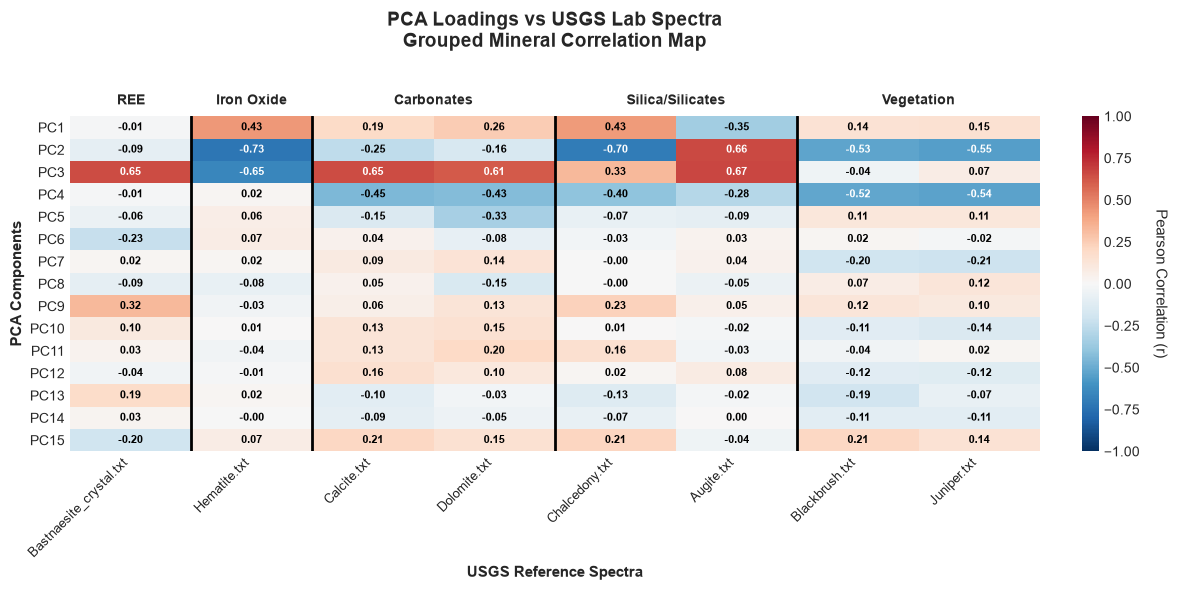

In [15]:
from src.ree_heatmap_viz import plot_pca_lab_correlation_heatmap

plot_pca_lab_correlation_heatmap(corr_matrix, spectrum_names, component_names)


## 9. Wavelet Decomposition Functions

In [16]:
def dwt_decompose(signal, wavelet='db4', level=5):
    '''Perform Discrete Wavelet Transform on a 1D signal.'''
    signal_clean = signal.copy()
    if np.any(np.isnan(signal_clean)):
        signal_clean[np.isnan(signal_clean)] = np.nanmean(signal_clean)
    coeffs = pywt.wavedec(signal_clean, wavelet, level=level)
    return coeffs

def extract_details(coeffs):
    '''Extract detail coefficients [cD_1, ..., cD_n] (fine → coarse).'''
    return coeffs[1:][::-1]

## 10. Decompose PCA Loadings and Lab Spectra

In [17]:
pc_wavelet_details = []
for i in range(N_PCA_COMPONENTS):
    loading = pca_loadings[:, i]
    coeffs = dwt_decompose(loading, WAVELET_TYPE, DECOMP_LEVEL)
    pc_wavelet_details.append(extract_details(coeffs))

usgs_wavelet_details = {}
for name, (wl, refl) in usgs_spectra.items():
    coeffs = dwt_decompose(refl, WAVELET_TYPE, DECOMP_LEVEL)
    usgs_wavelet_details[name] = extract_details(coeffs)

print(f' Decomposed {N_PCA_COMPONENTS} PC loadings and {len(usgs_wavelet_details)} lab spectra')


 Decomposed 15 PC loadings and 8 lab spectra


## 11. Wavelet Scale-wise Correlation

In [18]:
from src.ree_heatmap_viz import compute_wavelet_correlation

correlation_results = {}
for lab_name, lab_details in usgs_wavelet_details.items():
    corr_matrix_w = np.zeros((N_PCA_COMPONENTS, DECOMP_LEVEL))
    pval_matrix_w = np.zeros((N_PCA_COMPONENTS, DECOMP_LEVEL))

    for i in range(N_PCA_COMPONENTS):
        pc_details = pc_wavelet_details[i]
        corrs, pvals = compute_wavelet_correlation(pc_details, lab_details)
        corr_matrix_w[i, :] = corrs
        pval_matrix_w[i, :] = pvals

    correlation_results[lab_name] = {'correlations': corr_matrix_w, 'p_values': pval_matrix_w}

print(f' Wavelet correlation computed for {len(correlation_results)} lab spectra')

 Wavelet correlation computed for 8 lab spectra


## 12. Visualize Correlation Heatmaps — Wavelet-Decomposed Spectra vs PCs

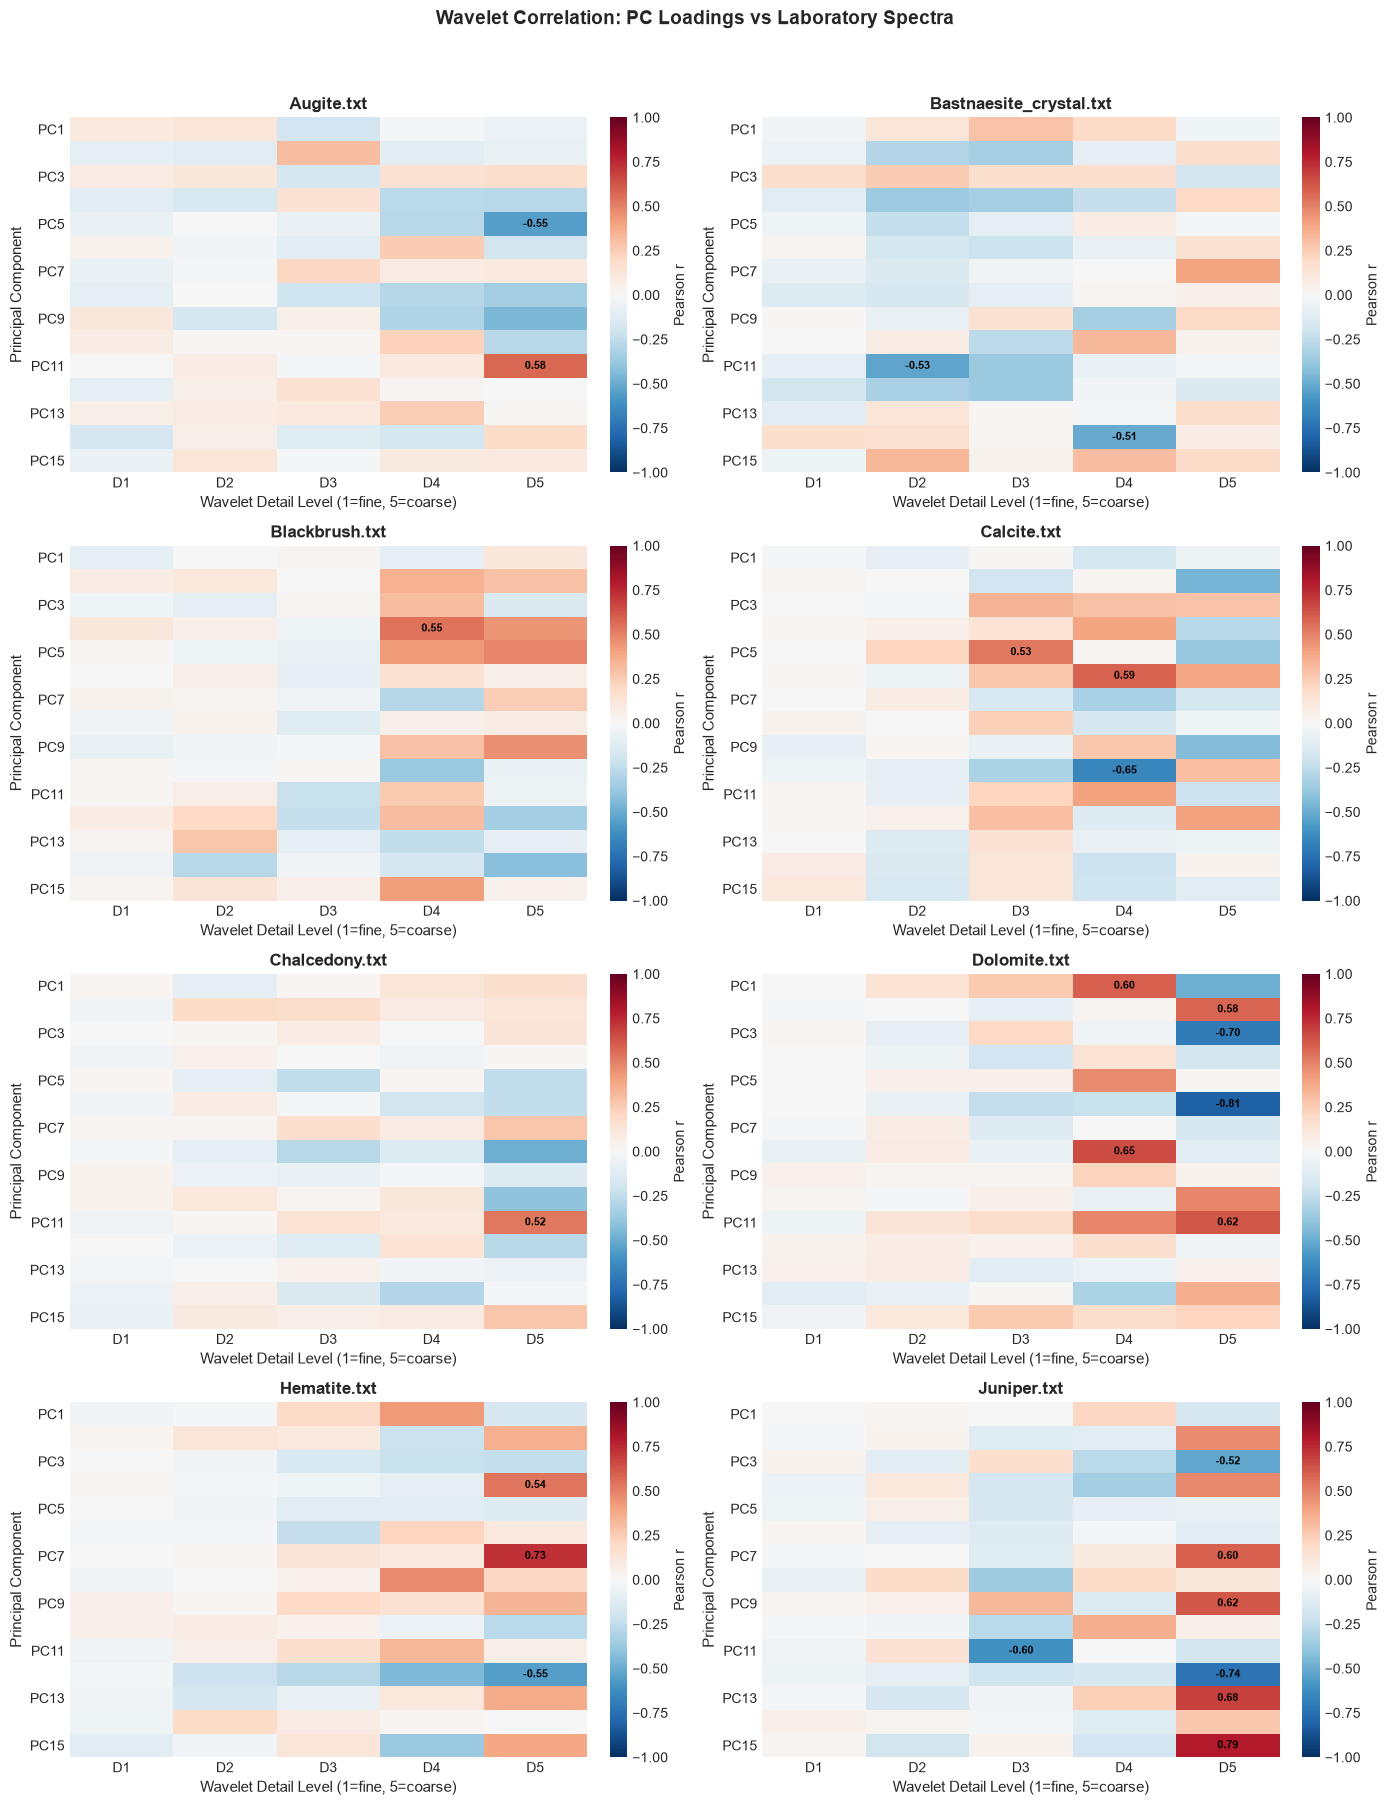

In [19]:
from src.ree_heatmap_viz import plot_wavelet_correlation_heatmaps

plot_wavelet_correlation_heatmaps(correlation_results, N_PCA_COMPONENTS, DECOMP_LEVEL)
